# Homework 04: Fitting, network flow, and project scheduling

**ISyE 524 — Fall 2026**  
**Due:** Monday, October 5, 2026, at 11:59 p.m. (Madison time).

Complete all three problems. Write each mathematical formulation before implementing it in Julia/JuMP. Define variables, domains, units where applicable, objective, and constraints. Use continuous variables throughout.

This assignment uses the piecewise-linear, minimax, network-flow, and project-scheduling material associated with Lectures 8–9. 

When submitting your problem to Gradescope, be sure to appropriately mark which pages of the PDF submission belong to which problem.  You won't get full marks unless you do that.


## Getting started and written answers

Follow [Assignments and PDF Submission](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/canvas-assignment-workflow.md). In VS Code, use **Tasks: Run Task** to run **ISyE 524: Update course repository**, then **ISyE 524: Start an assignment from its template**, entering `hw04`. Open `student-work/hw04/hw04.ipynb`. An existing working copy will not be overwritten.

For **every written part**, type LaTeX mathematics in Markdown or insert a clear photograph/scan of handwritten work. Include the answer and reasoning together and label the subparts; no duplicate transcription is required. Julia/JuMP implementations belong in code cells.

Use `$x_1 \geq 0$` for inline mathematics and `$$x_1+x_2\leq5$$` for display mathematics. Run the Markdown cell to render it.

For handwritten work, edit a Markdown cell in VS Code, drag in a cropped PNG/JPEG, and choose **Insert Image as Attachment**. Alternatively, put the image beside your working notebook under `student-work/hw04/images/` and insert `![My answer](images/problem1.png)`. Keep external images with the notebook. See [Images and handwritten work](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/assignments.md#images-and-handwritten-work).

Back up `student-work/hw04/` separately; Git does not back up your answers or images. After completing the notebook, export it with the course PDF task, inspect `submissions/hw04.pdf` for readable mathematics, tables, outputs, and images, and submit that PDF to Gradescope.


## Computational setup

Use JuMP and HiGHS for all models. Print the solver's termination status and check for `MOI.OPTIMAL` and an available solution before reading values. Check constraints using unrounded values.

The small fitting instance, network, and stadium data are supplied below. Keep `data/regression-large.csv` with this notebook; Problem 1(c) reads it with CSV.jl and DataFrames.jl. All supplied cells run without completed answers. Avoid printing entire large matrices or models in your submission.

AI tools may help debug your own code, explain syntax or error messages, and critique your work. They should not replace constructing your formulation, implementation, or written solution. Complete the required collaboration and LLM-use statement at the end.


In [199]:
using JuMP, HiGHS, CSV, DataFrames, Printf
import MathOptInterface as MOI


## 1: Fitting equations when they do not agree

Several measurements of an unknown vector $x$ give the following inconsistent system:

$$
\begin{aligned}
 2x_1-x_2+3x_3 &= 15,\\
 -x_1+4x_2+2x_4 &= -9,\\
 3x_1+x_2-2x_3+x_4 &= -5,\\
 2x_2+x_3-3x_4 &= 8,\\
 x_1-2x_2+4x_4 &= -3,\\
 4x_1+x_3-x_4 &= 17,\\
 -2x_1+3x_2+2x_3+x_4 &= -1,\\
 x_1+x_2-x_3+2x_4 &= -8.
\end{aligned}
$$

The coefficients $x_j$ are **unrestricted in sign**. We seek an approximate fit, rather than insist that every equation hold exactly.

More generally, let $M$ index measurements and $N$ index unknown coefficients. The data are $a_{ij}$ and $b_i$. For any proposed $x$, define its signed error and absolute residual by

$$
e_i(x)=\sum_{j\in N}a_{ij}x_j-b_i,
\qquad r_i(x)=|e_i(x)| \quad (i\in M).
$$

### 1(a): Minimum total absolute error — the $L_1$ fit

Write a **general indexed LP** that minimizes $\sum_{i\in M}r_i(x)$.  A formulation whose objective still contains absolute values is not yet an LP formulation.


**Your mathematical formulation and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]



$$
\begin{aligned}
\min\quad \sum_{i\in M}r_i(x)\\
\end{aligned}
$$  


$$
\begin{aligned}
\text{Subject To:}\\
\ r_i(x)=e_i(x) \quad (i\in M) \\
\ e_i(x) \geq \sum_{j\in N}a_{ij}x_j-b_i \\
\ e_i(x) \geq -\sum_{j\in N}a_{ij}x_j-b_i \\
\ e_i(x) \geq 0 \\
\end{aligned}
$$  


### Supplied data for the small instance

Here `A_small[i,j]` is $a_{ij}$ and `b_small[i]` is $b_i$. Implement your model from 1(a), solve this instance, and report the four coefficients, minimum total absolute error, and the absolute residual of each equation.


In [200]:
A_small = Float64[
     2 -1  3  0
    -1  4  0  2
     3  1 -2  1
     0  2  1 -3
     1 -2  0  4
     4  0  1 -1
    -2  3  2  1
     1  1 -1  2
]
b_small = Float64[15, -9, -5, 8, -3, 17, -1, -8]
println("Small instance: ", size(A_small, 1), " equations, ",
        size(A_small, 2), " unknown coefficients.")

m,n = size(A_small)


Small instance: 8 equations, 4 unknown coefficients.


(8, 4)

In [201]:
# Write your Julia/JuMP implementation here.
small=Model(HiGHS.Optimizer)

@variable(small,x[j in 1:n])

@variable(small, e[i in 1:m]>=0)

@constraint(small,E_upper[i in 1:m],
    e[i]  >= sum(A_small[i,j]*x[j]-b_small[i] for j in 1:n))

@constraint(small,E_lower[i in 1:m],
    e[i]  >= -sum(A_small[i,j]*x[j]-b_small[i] for j in 1:n))

@objective(small, Min, sum(e[i] for i in 1:m))

optimize!(small)
status = termination_status(small)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(small) || error("No feasible optimal solution is available.")

minimum_residual = objective_value(small)

println("Minimum Absolute error: ", minimum_residual)
println("")

xvalues = DataFrame(
    x_values = value.(x),
)


Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 16 rows; 12 cols; 70 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 4e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [4e+00, 7e+01]
Presolving model
16 rows, 12 cols, 70 nonzeros 0s
16 rows, 12 cols, 70 nonzeros 0s
Presolve reductions: rows 16(-0); columns 12(-0); nonzeros 70(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8(264); Du: 0(7.61267e-12) 0.0s
         11     3.1440000000e+01 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 11
Objective value     :  3.1440000000e+01
P-D objective error :  3.8930801114e-16
HiGHS run time      :          0.00
Termination status: OPTIMAL
Minimum Absolute error: 31.440

Row,x_values
,Float64
1,6.8
2,-3.56
3,14.28
4,-8.28


In [202]:
rvalues = DataFrame(
    residuals = value.(e),
)

Row,residuals
,Float64
1,-0.0
2,1.6
3,0.0
4,0.0
5,7.2
6,18.24
7,0.0
8,4.4


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]

The minimum ablsolute error is 31.44 with individual residuals of 0, 1.6, 0, 0, 7.2, 18.24, 0, 4.4 for equtations 1-8 respectively. The final values for x are $x_1=6.8$, $x_2=-3.56$, $x_3=14.28$, $x_4=-8.28$

### 1(b): Minimum worst error — the $L_\infty$ fit

Write a general indexed LP that minimizes $\max_{i\in M}r_i(x)$, and explain its equivalence to the minimax problem. Implement it for the same small instance.

Report the four fitted coefficients and every absolute residual. Make a two-row comparison table: for each fit, report **both** the sum of absolute residuals and the largest absolute residual. Explain what each objective sacrifices to improve its own measure. Would a single signed bound on the errors suffice? Explain.


**Your mathematical formulation and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]



$$
\begin{aligned}
\min\quad t \\
\end{aligned}
$$  


$$
\begin{aligned}
\text{Subject To:}\\
\ t \geq  r_i(x) \quad (i\in M)\\
\ r_i(x)=e_i(x) \quad (i\in M) \\
\ e_i(x) \geq \sum_{j\in N}a_{ij}x_j-b_i \\
\ e_i(x) \geq -\sum_{j\in N}a_{ij}x_j-b_i \\
\ e_i(x) \geq 0 \\
\end{aligned}
$$  

To produce a formulation equivelent to the minimax problem I added a variable t which must be greater than or equal to the largest residual value, (this is the maximum part). Then I make a new objective function that minimizes t.

In [203]:
# Write your Julia/JuMP implementation here.
inf=Model(HiGHS.Optimizer)

@variable(inf,x[j in 1:n])

@variable(inf, e[i in 1:m]>=0)

@variable(inf, t >=0)

@constraint(inf,E_upper[i in 1:m],
    e[i]  >= sum(A_small[i,j]*x[j]-b_small[i] for j in 1:n))

@constraint(inf,E_lower[i in 1:m],
    e[i]  >= -sum(A_small[i,j]*x[j]-b_small[i] for j in 1:n))

@constraint(inf, ma[i in 1:m],
    t >= e[i])

@objective(inf, Min, t)

optimize!(inf)
status = termination_status(inf)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(inf) || error("No feasible optimal solution is available.")

largest_residual = objective_value(inf)


println("Minimum Absolute error: ", largest_residual)
println("")

xvalues_inf = DataFrame(
    x_values_inf = value.(x),
)

combined_x=hcat(xvalues,xvalues_inf) #used Gemini to find this hcat funciton

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 24 rows; 13 cols; 86 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 4e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [4e+00, 7e+01]
Presolving model
24 rows, 13 cols, 86 nonzeros 0s
21 rows, 10 cols, 80 nonzeros 0s
18 rows, 7 cols, 74 nonzeros 0s
16 rows, 5 cols, 70 nonzeros 0s
16 rows, 5 cols, 70 nonzeros 0s
Presolve reductions: rows 16(-8); columns 5(-8); nonzeros 70(-16) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8(264); Du: 0(7.24557e-12) 0.0s
          7     6.5523809524e+00 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  6.5523809524e

Row,x_values,x_values_inf
,Float64,Float64
1,6.8,9.48571
2,-3.56,-3.80952
3,14.28,14.5905
4,-8.28,-8.91429


In [204]:
rvalues_inf = DataFrame(
    residuals_inf = value.(e),
)

combined_r=hcat(rvalues, rvalues_inf)

Row,residuals,residuals_inf
,Float64,Float64
1,-0.0,6.55238
2,1.6,6.55238
3,0.0,6.55238
4,0.0,6.55238
5,7.2,6.55238
6,18.24,6.55238
7,0.0,6.55238
8,4.4,6.55238


In [205]:
println("Total Error is: ", sum.(eachcol(rvalues_inf)), " for the infinite norm case")
println("Total Error is: ", sum.(eachcol(rvalues)), " for the first norm case")
println("")
println("Largest infinite norm residual is: ", largest_residual)
println("Largest first norm residual is: ", maximum(Matrix(rvalues))) 

Total Error is: [52.41904761904766] for the infinite norm case
Total Error is: [31.44000000000001] for the first norm case

Largest infinite norm residual is: 6.5523809523809575
Largest first norm residual is: 18.240000000000002


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


In the first norm residual you comprimise your highest residual for a lower total residual, thus meaning you fit most of the equations really good but dont fit one partilarly well. On the other hand in the inifinte norm case you sacrifise overall error for having very low error to each equation. This means you fit each eqation relitively equally but dont fit the whole system as well as the first norm case.

Single signed bounds on the error function in a error minimization problem would not suffice as it would cause an unbounded problem. This is because the error values being infinite and negitive would create the "smallest" error possible even though the error would be huge and just negitive.  This is why error minization must always be absolute valued. 


### 1(c): The same models at a larger scale

The file `data/regression-large.csv` contains a **fixed synthetic instance with 1,200 equations and 60 unknown coefficients**. All entries are dimensionless. Each row contains:

- `equation`: a row identifier, not a coefficient;
- `a01` through `a60`: the coefficients $a_{i1},\ldots,a_{i60}$;
- `b`: the observed right-hand side $b_i$.


Run the supplied CSV/DataFrames cell and inspect the preview. Reuse your general formulations from 1(a)–1(b) to solve **both** fits. Report:

1. A two-row table of total absolute error and maximum absolute error, computed from the fitted coefficients and the original data.

No new mathematical formulation or printout of all 1,200 residuals is required.


In [206]:
# Locate this assignment when the kernel starts beside the notebook or
# at the repository root. Prefer an existing personal copy.
assignment_dir = if isfile(joinpath(pwd(), "hw04.ipynb"))
    pwd()
elseif isdir(joinpath(pwd(), "student-work", "hw04"))
    joinpath(pwd(), "student-work", "hw04")
else
    joinpath(pwd(), "assignments", "hw04")
end
data_dir = joinpath(assignment_dir, "data")
data_path = joinpath(data_dir, "regression-large.csv")
isfile(data_path) || error(
    "Missing regression-large.csv in $(data_dir). " *
    "Keep the complete data folder beside your HW04 notebook."
)
regression_data = CSV.read(data_path, DataFrame)
coefficient_columns = filter(
    name -> startswith(name, "a"), names(regression_data))
A_large = Matrix{Float64}(regression_data[:, coefficient_columns])
b_large = Vector{Float64}(regression_data.b)
equation_ids = regression_data.equation
M_large = axes(A_large, 1)
N_large = axes(A_large, 2)

@assert length(unique(equation_ids)) == length(equation_ids)
@assert size(A_large, 1) == length(b_large)
@assert all(isfinite, A_large) && all(isfinite, b_large)
println("CSV instance: ", length(M_large), " equations, ",
        length(N_large), " unknown coefficients.")
first(regression_data[:, [:equation, :a01, :a02, :a03, :b]], 5)


CSV instance: 1200 equations, 60 unknown coefficients.


Row,equation,a01,a02,a03,b
,Int64,Int64,Int64,Int64,Float64
1,1,-3,1,-1,76.3728
2,2,5,0,-1,42.5359
3,3,-3,-5,5,37.3637
4,4,3,5,3,-12.6925
5,5,4,-2,-3,-36.9703


In [207]:
# Write your Julia/JuMP implementation here.

n_large=length(N_large)
m_large=length(M_large)

large=Model(HiGHS.Optimizer)

@variable(large,x[j in 1:n_large])

@variable(large, e[i in 1:m_large]>=0)

@constraint(large,E_upper[i in 1:m_large],
    e[i]  >= sum(A_large[i,j]*x[j]-b_large[i] for j in 1:n_large))

@constraint(large,E_lower[i in 1:m_large],
    e[i]  >= -sum(A_large[i,j]*x[j]-b_large[i] for j in 1:n_large))

@objective(large, Min, sum(e[i] for i in 1:m_large))

optimize!(large)
status = termination_status(large)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(large) || error("No feasible optimal solution is available.")

minimum_residual_large = objective_value(large)

println("Minimum Absolute error: ", minimum_residual_large)
println("")

xvalues_large = DataFrame(
    x_values_large = value.(x),
)

rvalues_large = DataFrame(
    residuals_large = value.(e),
)


Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 2400 rows; 1260 cols; 133388 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 5e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [9e+00, 1e+04]
Presolving model
2400 rows, 1260 cols, 133388 nonzeros 0s
2400 rows, 1260 cols, 133388 nonzeros 0s
Presolve reductions: rows 2400(-0); columns 1260(-0); nonzeros 133388(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 1200(3.14612e+06); Du: 0(1.89107e-09) 0.0s
       2272     8.2851611436e+04 Pr: 0(0) 0.8s

Model status        : Optimal
Simplex   iterations: 2272
Objective value     :  8.2851611436e+04
P-D objective error :  1.5807350565e-15
HiGHS run time      :          0.78
Termination s

Row,residuals_large
,Float64
1,15.4508
2,8.325
3,8.01585
4,34.6843
5,11.6383
6,42.597
7,28.2575
8,5.85821
9,38.3587


In [208]:
inf_large=Model(HiGHS.Optimizer)

@variable(inf_large,x[j in 1:n_large])

@variable(inf_large, e[i in 1:m_large]>=0)

@variable(inf_large, t >=0)

@constraint(inf_large,E_upper[i in 1:m_large],
    e[i]  >= sum(A_large[i,j]*x[j]-b_large[i] for j in 1:n_large))

@constraint(inf_large,E_lower[i in 1:m_large],
    e[i]  >= -sum(A_large[i,j]*x[j]-b_large[i] for j in 1:n_large))

@constraint(inf_large, ma[i in 1:m_large],
    t >= e[i])

@objective(inf_large, Min, t)

optimize!(inf_large)
status = termination_status(inf_large)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(inf_large) || error("No feasible optimal solution is available.")

largest_residual_large = objective_value(inf_large)


println("Minimum Absolute error: ", largest_residual_large)
println("")

xvalues_inf_large = DataFrame(
    x_values_inf_large = value.(x),
)

combined_x_large=hcat(xvalues_large,xvalues_inf_large) #used Gemini to find this hcat funciton

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 3600 rows; 1261 cols; 135788 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 5e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [9e+00, 1e+04]
Presolving model
3600 rows, 1261 cols, 135788 nonzeros 0s
3235 rows, 896 cols, 135058 nonzeros 2s
2925 rows, 586 cols, 134438 nonzeros 5s
2661 rows, 322 cols, 133910 nonzeros 9s
2437 rows, 98 cols, 133462 nonzeros 13s
2400 rows, 61 cols, 133388 nonzeros 14s
Presolve reductions: rows 2400(-1200); columns 61(-1200); nonzeros 133388(-2400) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 1200(3.14612e+06); Du: 0(2.12961e-09) 14.0s
        229     9.7696438091e+02 Pr: 0(0) 14.1s

Performed postsolve
Solving the original LP from the s

Row,x_values_large,x_values_inf_large
,Float64,Float64
1,-60.4496,-42.3492
2,90.7319,102.142
3,-120.082,-103.992
4,150.56,164.138
5,-181.514,-124.107
6,210.006,225.164
7,-29.7231,-18.6531
8,59.8513,64.6369
9,-89.1353,-75.2902


In [209]:
rvalues_inf_large = DataFrame(
    residuals_inf_large = value.(e),
)

combined_r_large=hcat(rvalues_large, rvalues_inf_large)

Row,residuals_large,residuals_inf_large
,Float64,Float64
1,15.4508,976.964
2,8.325,976.964
3,8.01585,976.964
4,34.6843,976.964
5,11.6383,976.964
6,42.597,976.964
7,28.2575,976.964
8,5.85821,976.964
9,38.3587,976.964


In [210]:
println("Total Error is: ", sum.(eachcol(rvalues_inf_large)), " for the infinite norm case")
println("Total Error is: ", sum.(eachcol(rvalues_large)), " for the first norm case")
println("")
println("Largest infinite norm residual is: ", largest_residual_large)
println("Largest first norm residual is: ", maximum(Matrix(rvalues_large))) 

Total Error is: [1.1723572570921765e6] for the infinite norm case
Total Error is: [82851.61143579039] for the first norm case

Largest infinite norm residual is: 976.9643809101464
Largest first norm residual is: 1555.6710856813586


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


| Norm Type | Total Absolute Error | Maximum Absolute error |
| --: | --: | --: |
| 1 | 82851.6 | 1555.7 |
| $ \infty $ | $1.1723*10^6$ | 977.0 |


Here the absoulte error explodes when you impose the minimax on the equation becase there is so many equations.

## 2: Minimum-cost distribution through a network

A distributor must move one interchangeable product through ten locations. Locations 1, 2, and 9 supply product; locations 6, 7, and 8 require it. The other locations are transfer points. Product can also pass through a location that has supply or demand.

The planning period has the following **net supplies** $b_i$: a positive number means supply, a negative number means demand, and zero means pure transshipment.

| Node $i$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
| :-- | --: | --: | --: | --: | --: | --: | --: | --: | --: | --: |
| $b_i$ (tons) | 10 | 15 | 0 | 0 | 0 | -12 | -11 | -7 | 5 | 0 |

Only the directed arcs in the following table are available. An arc from $i$ to $j$ does **not** imply that the reverse arc exists. Every arc has lower bound zero, cost $c_{ij}$ dollars per ton, and capacity $u_{ij}$ tons. All listed supply must be shipped and all listed demand must be met exactly. There is no loss in transit.

| From | To | Cost ($/ton) | Capacity (tons) |
| --: | --: | --: | --: |
| 1 | 3 | 5 | 15 |
| 2 | 4 | 4 | 20 |
| 3 | 4 | 2 | 12 |
| 3 | 5 | 6 | 10 |
| 3 | 6 | 5 | 10 |
| 4 | 5 | 1 | 10 |
| 4 | 8 | 2 | 10 |
| 5 | 3 | 4 | 8 |
| 5 | 6 | 6 | 10 |
| 5 | 7 | 3 | 15 |
| 8 | 7 | 4 | 8 |
| 9 | 3 | 3 | 5 |
| 9 | 10 | 2 | 5 |
| 10 | 5 | 1 | 6 |
| 10 | 8 | 4 | 4 |
| 3 | 10 | 2 | 6 |

### 2(a): Mathematical formulation

Write a general minimum-cost network-flow LP using node set $N$, arc set $A$, net supplies $b_i$, costs $c_{ij}$, and capacities $u_{ij}$. Let $f_{ij}$ be the flow on arc $(i,j)$. Explain your flow-balance sign convention and why the sum of all net supplies must be zero. Use variables only for existing arcs.


**Your mathematical formulation and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


$$
\begin{aligned}
\min \quad \sum_{(i,j) \epsilon \varepsilon} f_{ij}c_{ij} \\
\end{aligned}
$$  


$$
\begin{aligned}
\text{Subject To:}\\
\ \sum_{(i,j) \epsilon \varepsilon}f_{ij} - \sum_{(i,j) \epsilon \varepsilon}f_{ji} = b_i \quad \forall i \epsilon N\\
\ 0 \leq f_{ij} \leq u_{ij} \quad \forall(i,j) \epsilon \varepsilon
\end{aligned}
$$  

Here it is important to have the sign conention be positive for flow out and negitive for flow in so that it agress with the sign convention of the problem where demand is negitive and supply is positive. Along with this it is important that the sum of all net supplies is zero so that this problem is balenced. if theis problem were unbalenced and had exact node balence equalities like is used in this problem it would be infeasable.  

### 2(b): Implement, solve, and check

Implement your formulation using the supplied data. Report the minimum total cost and all positive arc flows. Give a check of the net outflow at every node and verify all capacity limits. Identify the arcs operating at capacity. Interpret the result as a shipment plan; integer declarations are not required.


In [211]:
N = 1:10
b = Dict(zip(N, [10, 15, 0, 0, 0, -12, -11, -7, 5, 0]))
# Each row is (from, to, cost, capacity).
arc_data = [
    (1, 3, 5, 15), (2, 4, 4, 20), (3, 4, 2, 12),
    (3, 5, 6, 10), (3, 6, 5, 10), (4, 5, 1, 10),
    (4, 8, 2, 10), (5, 3, 4, 8), (5, 6, 6, 10),
    (5, 7, 3, 15), (8, 7, 4, 8), (9, 3, 3, 5),
    (9, 10, 2, 5), (10, 5, 1, 6), (10, 8, 4, 4),
    (3, 10, 2, 6)
]
A = [(i, j) for (i, j, cost, capacity) in arc_data]
c = Dict((i, j) => cost for (i, j, cost, capacity) in arc_data)
u = Dict((i, j) => capacity for (i, j, cost, capacity) in arc_data)
println("Network: ", length(N), " nodes, ",
    length(A), " directed arcs.")

    

Network: 10 nodes, 16 directed arcs.


In [212]:
# Write your Julia/JuMP implementation here.

mcn=Model(HiGHS.Optimizer)

@variable(mcn, f[(i,j) in A]>=0)

@constraint(mcn, flowbalance[i in N],
    sum(f[(i,j)] for j in N if (i,j) in A) -
    sum(f[(j,i)] for j in N if (j,i) in A)
    == b[i])

@constraint(mcn, capacity[(i,j) in A],
    (f[(i,j)] <= u[(i,j)]))

@objective(mcn, Min, 
    sum(c[i,j]*f[(i,j)] for (i,j) in A))



optimize!(mcn)
status = termination_status(mcn)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(mcn) || error("No feasible optimal solution is available.")

min_cost= objective_value(mcn)

println("Minimum Cost if: ", min_cost, " Dollars")
println()

flows = DataFrame(
    flows = value.(f[(i,j)] for (i,j) in A),
    to_from = collect(A),
    capacity = collect(u[(i,j)] for (i,j) in A)
)



Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 26 rows; 16 cols; 48 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+00, 6e+00]
  Bound   [0e+00, 0e+00]
  RHS     [4e+00, 2e+01]
Presolving model
5 rows, 11 cols, 22 nonzeros 0s
Dependent equations search running on 5 equations with time limit of 1000.00s
Dependent equations search removed 1 rows and 6 nonzeros in 0.00s (limit = 1000.00s)
4 rows, 11 cols, 16 nonzeros 0s
Presolve reductions: rows 4(-22); columns 11(-5); nonzeros 16(-32) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          3     2.4200000000e+02 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   itera

Row,flows,to_from,capacity
,Float64,Tuple…,Int64
1,10.0,"(1, 3)",15
2,15.0,"(2, 4)",20
3,0.0,"(3, 4)",12
4,0.0,"(3, 5)",10
5,10.0,"(3, 6)",10
6,8.0,"(4, 5)",10
7,7.0,"(4, 8)",10
8,0.0,"(5, 3)",8
9,2.0,"(5, 6)",10


In [213]:
net_flows = DataFrame(
    net_flow_out = [sum(value(f[(i,j)]) for j in N if (i,j) in A;
     init=0.0) for i in N],
    net_flow_in  = [sum(value(f[(j,i)]) for j in N if (j,i) in A;
     init=0.0) for i in N],
    b_expected=[b[i] for i in N]
)

net_flows.net_flow = net_flows.net_flow_out - net_flows.net_flow_in

net_flows

Row,net_flow_out,net_flow_in,b_expected,net_flow
,Float64,Float64,Int64,Float64
1,10.0,0.0,10,10.0
2,15.0,0.0,15,15.0
3,10.0,10.0,0,0.0
4,15.0,15.0,0,0.0
5,13.0,13.0,0,0.0
6,0.0,12.0,-12,-12.0
7,0.0,11.0,-11,-11.0
8,0.0,7.0,-7,-7.0
9,5.0,0.0,5,5.0


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]

Implement your formulation using the supplied data. Report the minimum total cost and all positive arc flows. Give a check of the net outflow at every node and verify all capacity limits. Identify the arcs operating at capacity. Interpret the result as a shipment plan; integer declarations are not required.


The minimum cost for this shipping plan is 242 dollars. Shippment Plan shown in image below.

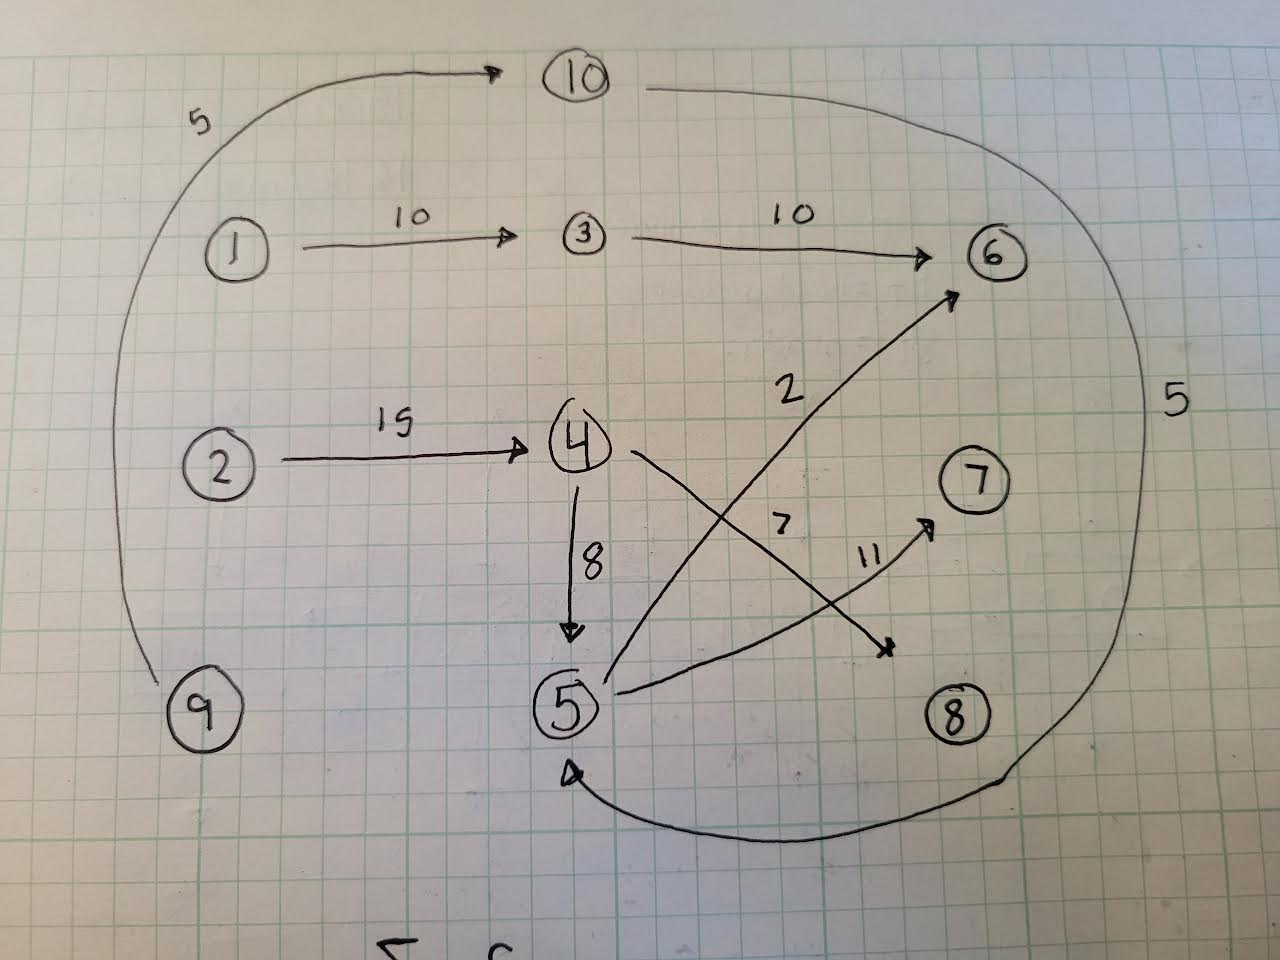

## 3: Stadium building

A town council wishes to construct a small stadium to improve local services. A construction company has won the contract and wants to plan the work. Some activities can begin only after their predecessors finish. Activities may otherwise proceed simultaneously; assume sufficient crews and equipment, with no shared-resource restrictions.

Time is measured in **weeks from the start of construction**, and week 0 is the earliest start. The following are the normal activity durations and immediate predecessors.

| Task | Description | Duration $d_i$ | Predecessors |
| --: | :-- | --: | :-- |
| 1 | Install construction site | 2 | none |
| 2 | Terracing | 16 | 1 |
| 3 | Construct foundations | 9 | 2 |
| 4 | Access roads and other networks | 8 | 2 |
| 5 | Erect basement | 10 | 3 |
| 6 | Main floor | 6 | 4, 5 |
| 7 | Divide changing rooms | 2 | 4 |
| 8 | Electrify terraces | 2 | 6 |
| 9 | Construct roof | 9 | 4, 6 |
| 10 | Stadium lighting | 5 | 4 |
| 11 | Install terraces | 3 | 6 |
| 12 | Seal roof | 2 | 9 |
| 13 | Finish changing rooms | 1 | 7 |
| 14 | Construct ticket office | 7 | 2 |
| 15 | Secondary access roads | 4 | 4, 14 |
| 16 | Install signs | 3 | 8, 11, 14 |
| 17 | Lawn and sports accessories | 9 | 12 |
| 18 | Hand over building | 1 | 17 |

**The project is complete only when all eighteen tasks are finished.** In particular, a task without successors still has to finish. Task 18 retains the predecessors listed in the table.

Let $T=\{1,\ldots,18\}$ and $P=\{(i,j):i\text{ immediately precedes }j\}$. This problem uses **predecessor first** in each pair. Let $x_i$ denote the start time of task $i$.

### 3(a): Earliest completion

Write a general LP for the minimum project completion time. Implement and solve it using the supplied data. Report the minimum time, a feasible start/finish schedule, and a critical path. Explain how the durations along that path certify that no shorter schedule is possible.


**Your mathematical formulation and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]

$$
\begin{aligned}
\min \quad  x_T +d_T
\end{aligned}
$$  


$$
\begin{aligned}
\text{Subject To:}\\
\ t_{1}=0\\
\ x_i \geq x_j + d_j\quad \forall j \in  \mathcal{P}_i \quad \forall i \in\mathcal{T} \\
\end{aligned}
$$  



In [214]:
T = 1:18
d = [2, 16, 9, 8, 10, 6, 2, 2, 9, 5, 3, 2, 1, 7, 4, 3, 9, 1]
pred = [Int[], [1], [2], [2], [3], [4,5], [4], [6],
        [4,6], [4], [6], [9], [7], [2], [4,14], [8,11,14],
        [12], [17]]
P = [(i, j) for j in T for i in pred[j]]
println("Stadium: ", length(T), " tasks and ",
    length(P), " precedence pairs.")


Stadium: 18 tasks and 22 precedence pairs.


In [215]:
# Write your Julia/JuMP implementation here.

stadium=Model(HiGHS.Optimizer)

@variable(stadium, x[i in T])

@constraint(stadium, start[(i,j) in P], x[j]>=x[i]+d[i]) 

@constraint(stadium, x[1] == 0)

@objective(stadium, Min, x[length(T)]+d[length(T)])

optimize!(stadium)
status = termination_status(stadium)
println("Termination status: ", status)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(stadium) || error("No feasible optimal solution is available.")

shortest_time= objective_value(stadium)

println("Shortest Possible time is: ",shortest_time,  " weeks")


println("Precedence-constraint slack (not task float):")
for i in T
    for j in pred[i]
       slack = value(x[i]) - value(x[j]) - d[j];
        if (slack <= .00001)
            println("task ", i, " predecessor ",j, "  slack is : ",
             slack," ***ACTIVE")
        else
            println("task ", i, " predecessor ",j, "  slack is : ",
             slack," ***FLOAT")
        end
    end
end

# Forward pass: earliest starts and a dependency order.
earliest = Dict{Int64,Float64}()
order = Int[]
while length(order) < length(T)
    ready = [i for i in T if !haskey(earliest, i) &&
             all(haskey(earliest, j) for j in pred[i])]
    isempty(ready) && error("The precedence graph contains a cycle")
    for i in ready
        earliest[i] = isempty(pred[i]) ? 0.0 :
            maximum(earliest[j] + d[j] for j in pred[i])
        push!(order, i)
    end
end

# Backward pass: latest starts consistent with the minimum makespan.
latest = Dict{Int64,Float64}()
for i in reverse(order)
    successors = [j for j in T if i in pred[j]]
    latest[i] = isempty(successors) ? objective_value(stadium) - d[i] :
        minimum(latest[j] - d[i] for j in successors)
end

total_float = Dict(i => latest[i] - earliest[i] for i in T)
critical = [i for i in order if abs(total_float[i]) <= 1e-7]
println("Critical activities (including dummy start/finish): ", critical)




Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 23 rows; 18 cols; 45 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [2e+00, 2e+01]
Presolving model
5 rows, 6 cols, 10 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-23); columns 0(-18); nonzeros 0(-45) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  6.4000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Termination status: OPTIMAL
Shortest Possible time is: 64.0 weeks
Precedence-constraint slack (not task float):
task 2 predecessor 1  slack is : 0.0 ***ACTIVE
task 3 predecessor 2  slack is : 0.0 ***ACTIVE
task 4 predecessor 2  slack is : 0.0 ***ACTIVE


In [216]:
start_time = DataFrame(
    start = value.(x).data,
    duration = collect(d)
)

Row,start,duration
,Float64,Int64
1,-0.0,2
2,2.0,16
3,18.0,9
4,18.0,8
5,27.0,10
6,37.0,6
7,26.0,2
8,43.0,2
9,43.0,9


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]

 The minimum time for this project is 64 weeks. This is constrained by a critical path of tasks 1,2,3,5,6,9,12,17,18.  This is the critial path becasue in each case the possible tasks that may follow take less time. Thus if you sum the durations of the critial path you should get the minimum project time.  

$d_1+d_2+d_3+d_5+d_6+d_9+d_{12}+d_{17}+d_{18} = 64$, $\quad$
 $2+16+9+10+6+9+2+9+1 = 64$

## Collaboration and LLM-use statement — required

Complete this statement as the **very last part of your homework**. Be specific enough that a reader can understand what work you did yourself and how others or LLMs helped you learn.

- **People:** Give the name of every person you collaborated with, identify the problem/subpart you discussed, and explain the nature of the collaboration. If you worked alone, explicitly state that you did not collaborate with anyone.
- **LLMs/tools:** Name every LLM or AI assistant you used and identify the model/version as precisely as available. If the interface did not show a model/version, say so. If you used none, explicitly state that you did not use an LLM or AI assistant.
- **Specific assistance and learning:** For each tool, identify the problem/subpart, describe what you asked it to help with, what suggestions you used or rejected, and how the interaction helped you understand the mathematics or implementation. Explain how you checked the suggestions. “I used ChatGPT for help” is not sufficiently specific.

Disclosure does not replace the requirement that your submitted formulation, implementation, and explanation be your own work and that you understand them.


**People and collaboration:**

[Names, problem/subparts, and what you discussed; or explicitly state that you worked alone.]

I worked alone.

**LLMs/tools and models:**

[Tool names and models/versions, or explicitly state that you used none.]

Google Gemini 3.5 flash Lite

**How I used the assistance, what I learned, and how I checked it:**

[Specific details for each tool and relevant problem/subpart; state not applicable if you used none.]

I used LLM to find the hcat function. I knew how to add dictioarys in python so I prompted this LLM with the way I would do it in python, concat([df1,dft], axis=1) and what the equivelent was in juila. I then implimented it and printed the results to make sure that it was doing what I intended.
